# ECGtizer Pipeline Vignette

This notebook walks through the **entire ECGtizer digitization pipeline** step by step,
showing the ECG image transformation at every stage.

We use a real 12-lead ECG PDF from the PTB-XL dataset included in the repository.

## Pipeline stages

| # | Stage | Function | Output |
|---|-------|----------|--------|
| 1 | PDF to Image | `convert_PDF2image` | RGB image |
| 2 | Noise & Format Detection | `check_noise_type` | TYPE, NOISE |
| 3 | Text Masking | `text_extraction` | Cleaned image |
| 4 | Track Segmentation | `tracks_extraction` | Sub-images per track |
| 5 | Track Cleaning | `clean_tracks` | Denoised tracks |
| 6 | Waveform Extraction | `lead_extraction` | Raw digital signals |
| 7 | Extraction Methods Comparison | lazy / full / fragmented | 3 algorithms |
| 8 | Lead Calibration & Naming | `lead_cutting` | Named leads in µV |
| 9 | 12-Lead ECG Plot | `plot_function` | Final result |
| 10 | Overlay Verification | manual overlay | Quality check |
| 11 | Export to XML | `write_xml` | HL7 aECG file |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os, sys

# Ensure the project root is on the path
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)

from ecgtizer.PDF2XML import (
    convert_PDF2image, check_noise_type, text_extraction,
    tracks_extraction, clean_tracks, lead_extraction, lead_cutting,
)
from ecgtizer.PDF2XML_mod import plot_function, write_xml
from ecgtizer.extraction_functions import (
    lazy_extraction, full_extraction, fragmented_extraction,
)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.facecolor"] = "white"

INPUT_PDF = "data/PTB-XL/PDF/00009_hr.pdf"
DPI = 500

print(f"Input file: {INPUT_PDF}")
print(f"Resolution: {DPI} DPI")

Input file: data/PTB-XL/PDF/00009_hr.pdf
Resolution: 500 DPI


---
## Stage 1 — PDF to Image

`convert_PDF2image` uses **poppler** (via `pdf2image`) to rasterize the PDF at the
requested DPI. The result is a list of NumPy RGB arrays, one per page.

Success: True
Pages:   1
Shape:   (4134, 5847, 3)  (height x width x channels)
Dtype:   uint8


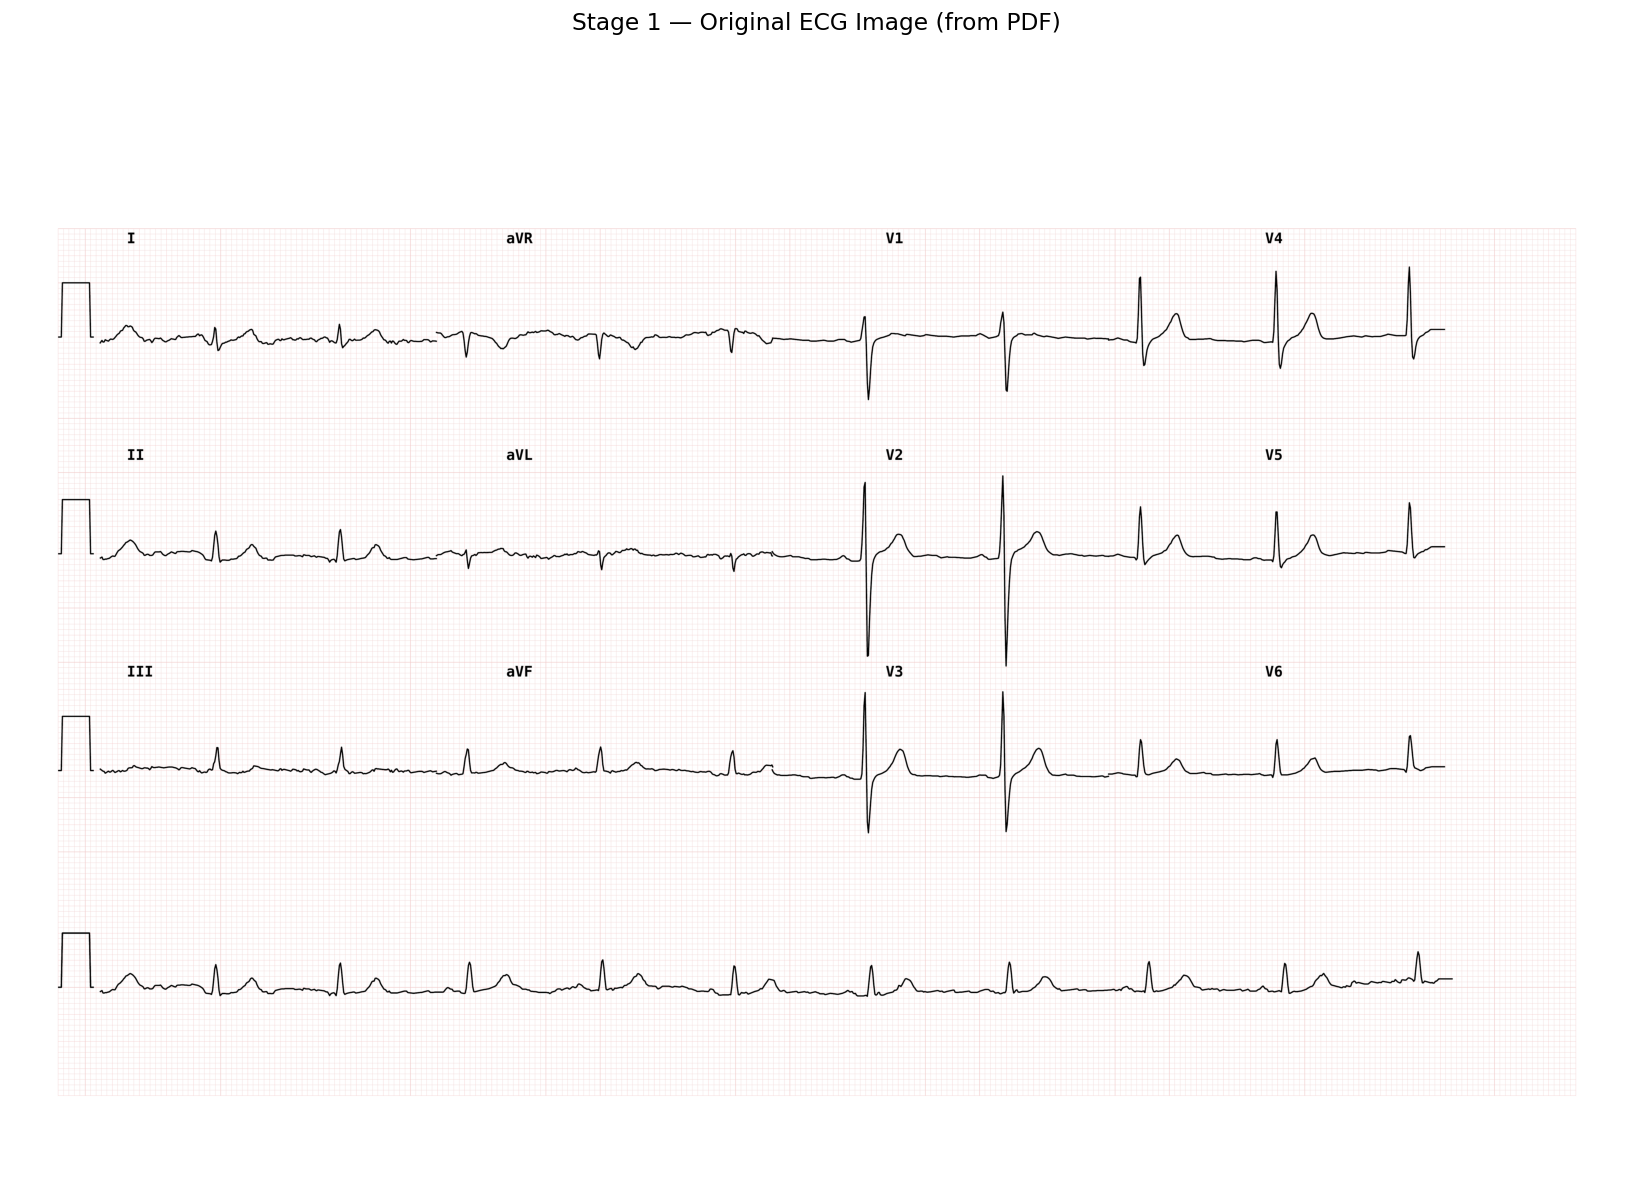

In [2]:
pages, num_pages, success = convert_PDF2image(INPUT_PDF, DPI=DPI)

image_original = np.array(pages[0])

print(f"Success: {success}")
print(f"Pages:   {num_pages}")
print(f"Shape:   {image_original.shape}  (height x width x channels)")
print(f"Dtype:   {image_original.dtype}")

fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(image_original)
ax.set_title("Stage 1 — Original ECG Image (from PDF)", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

---
## Stage 2 — Noise & Format Detection

`check_noise_type` analyses the image variance to determine:
- **TYPE**: ECG format (`classic`, `kardia`, `wellue`, `apple`)
- **NOISE**: Whether the background is noisy (`True`, `False`, or `0.5` for partial)

In [3]:
image = image_original.copy()
TYPE, NOISE = check_noise_type(image, DPI=DPI, DEBUG=False)

variance = np.var(image)

print(f"Detected format : {TYPE}")
print(f"Noise detected  : {NOISE}")
print(f"Image variance  : {variance:.0f}")
print()
print("Variance thresholds:")
print("  < 600          → very clean")
print("  600 – 2000     → clean (NOISE=False)")
print("  2000 – 3000    → partial noise (NOISE=0.5)")
print("  > 3000         → noisy (NOISE=True)")

Detected format : classic
Noise detected  : False
Image variance  : 612

Variance thresholds:
  < 600          → very clean
  600 – 2000     → clean (NOISE=False)
  2000 – 3000    → partial noise (NOISE=0.5)
  > 3000         → noisy (NOISE=True)


---
## Stage 3 — Text Masking

`text_extraction` detects patient-identifying text (name, ID, date) and
annotations in the header area, then masks them with white or mean-coloured
pixels. This prevents text from interfering with waveform extraction.

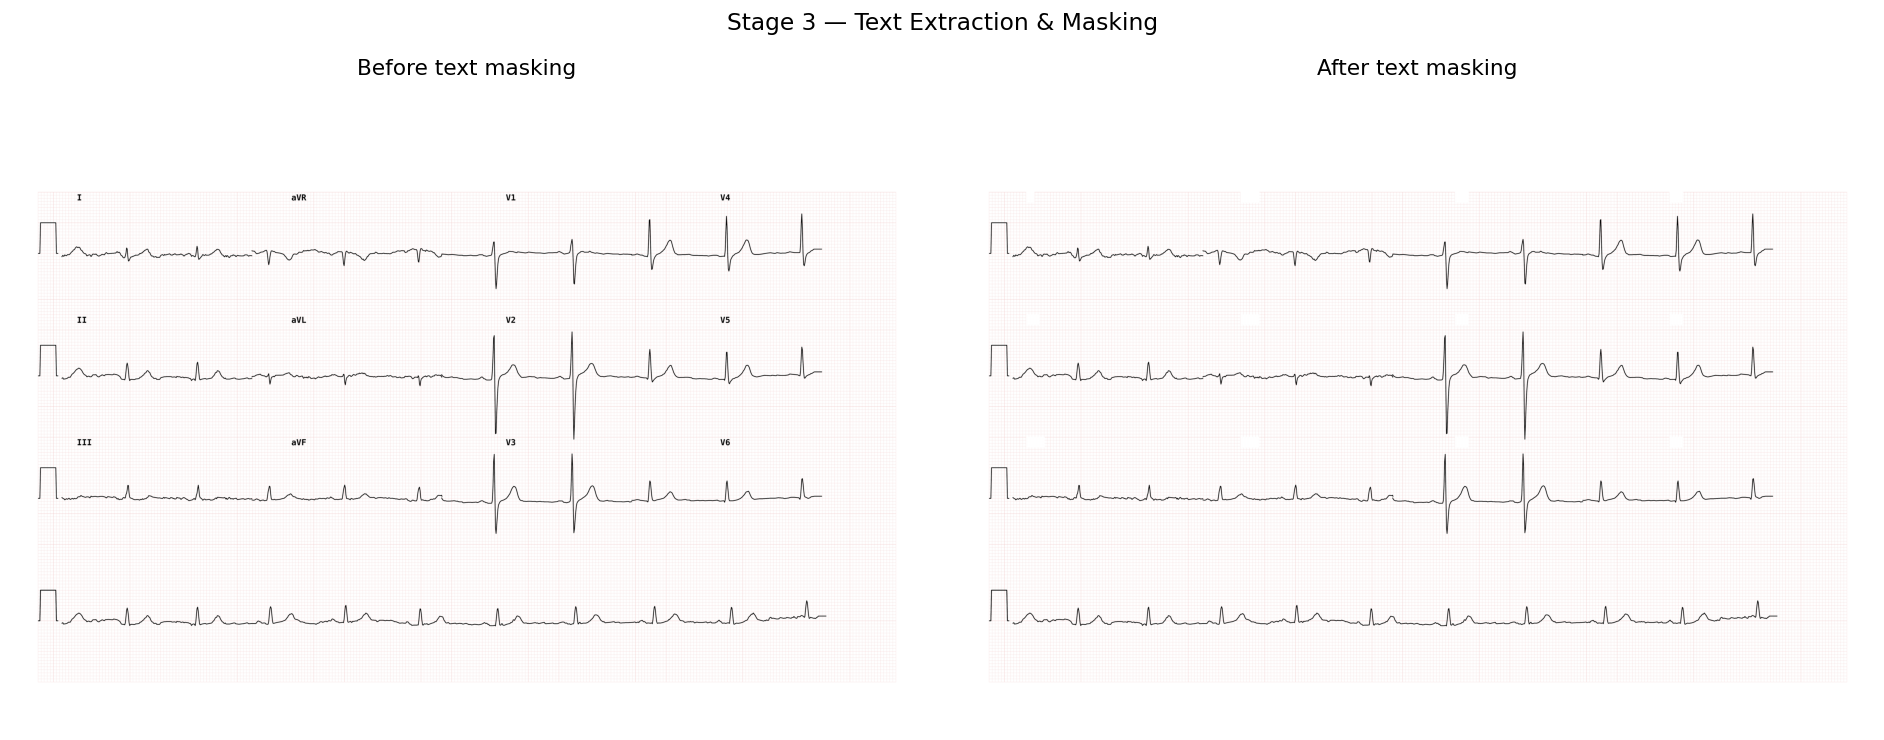

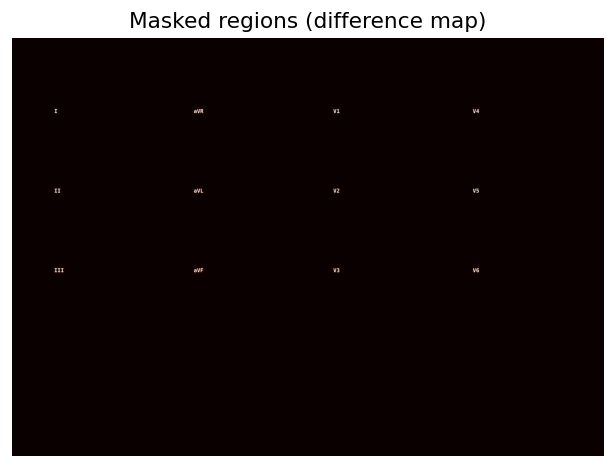

In [4]:
# Keep a copy before masking
image_before_mask = image.copy()

image_clean = text_extraction(image, page=0, DPI=DPI, NOISE=NOISE, TYPE=TYPE, DEBUG=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(image_before_mask)
axes[0].set_title("Before text masking", fontsize=13)
axes[0].axis("off")

axes[1].imshow(image_clean)
axes[1].set_title("After text masking", fontsize=13)
axes[1].axis("off")

fig.suptitle("Stage 3 — Text Extraction & Masking", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Show the difference (what was masked)
diff = np.abs(image_before_mask.astype(float) - image_clean.astype(float)).sum(axis=2)
if diff.max() > 0:
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.imshow(diff, cmap="hot")
    ax.set_title("Masked regions (difference map)", fontsize=13)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

---
## Stage 4 — Track Segmentation

`tracks_extraction` analyses the **horizontal variance** (variance per row)
to find peaks that correspond to ECG trace lines. It cuts the image into
individual tracks and trims them vertically using the **vertical variance**.

In [5]:
dic_tracks, peaksh, peaksv = tracks_extraction(
    image_clean, TYPE, DPI=DPI, FORMAT="", NOISE=NOISE, DEBUG=False
)

print(f"Number of tracks: {len(dic_tracks)}")
print(f"Horizontal peaks (row positions): {list(peaksh)}")
print(f"Vertical signal start (column):   {peaksv}")
print()
for tid, track_img in dic_tracks.items():
    print(f"  Track {tid}: shape {track_img.shape}")

Number of tracks: 4
Horizontal peaks (row positions): [np.int64(1081), np.int64(1876), np.int64(2659), np.int64(3457)]
Vertical signal start (column):   167

  Track 0: shape (1272, 5037)
  Track 1: shape (789, 5037)
  Track 2: shape (791, 5037)
  Track 3: shape (704, 5037)


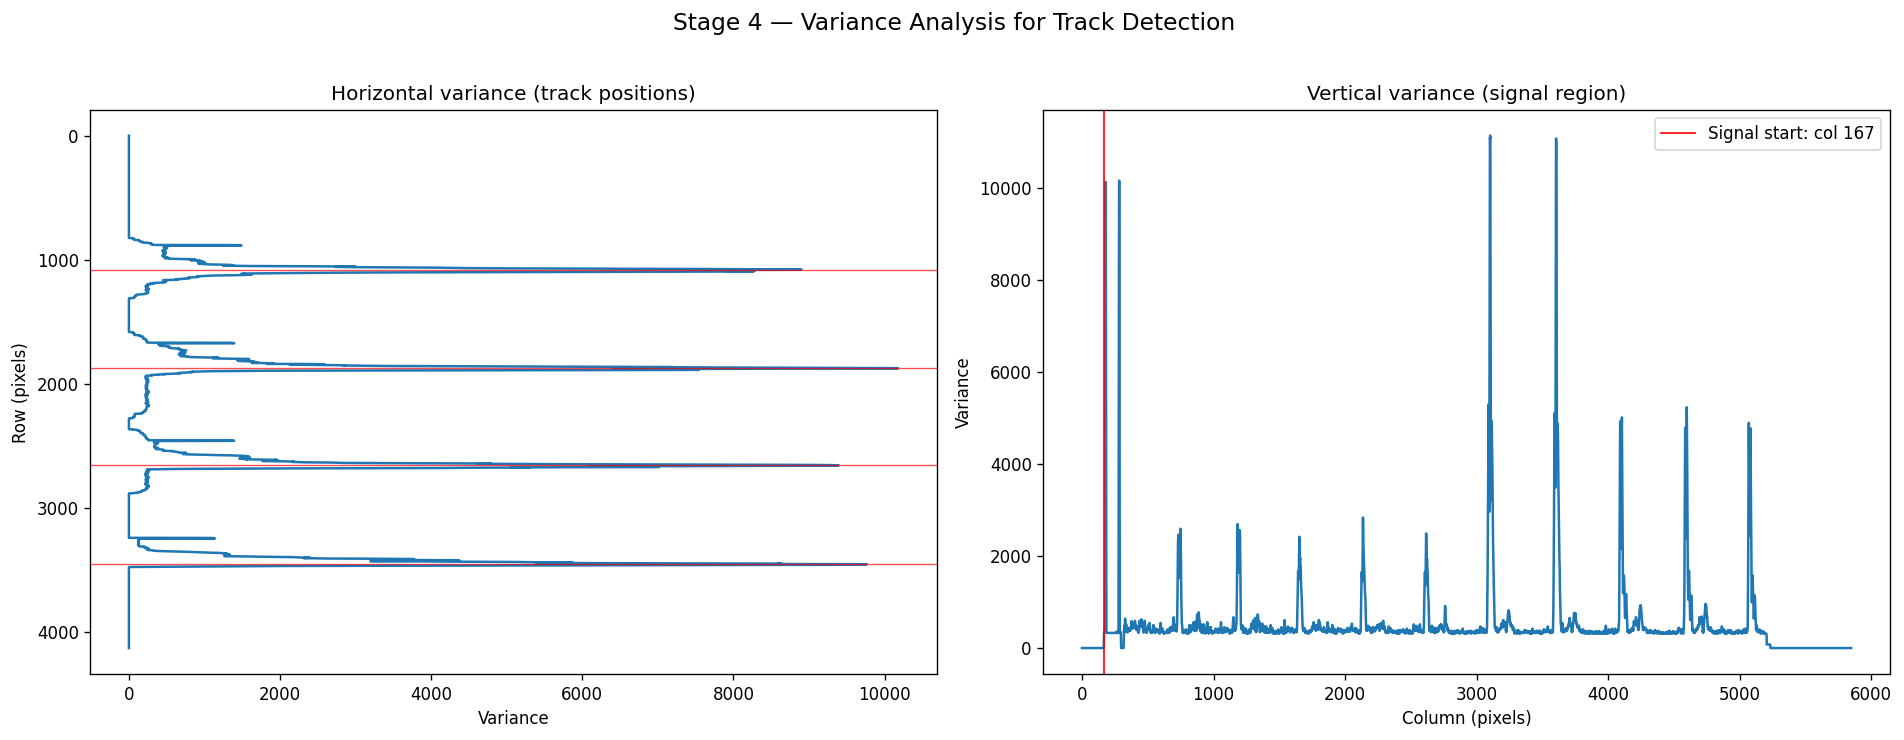

In [6]:
import cv2

# Recompute horizontal variance for visualisation
gray = cv2.cvtColor(image_clean, cv2.COLOR_BGR2GRAY)
_, image_bin_viz = cv2.threshold(
    cv2.GaussianBlur(gray, (5, 5), 0), 0, 255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU,
)
horizontal_variance = np.var(image_bin_viz, axis=1)
vertical_variance = np.var(image_bin_viz, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Horizontal variance
axes[0].plot(horizontal_variance, range(len(horizontal_variance)))
for p in peaksh:
    axes[0].axhline(p, color="red", linewidth=0.8, alpha=0.7)
axes[0].invert_yaxis()
axes[0].set_xlabel("Variance")
axes[0].set_ylabel("Row (pixels)")
axes[0].set_title("Horizontal variance (track positions)")

# Vertical variance
axes[1].plot(vertical_variance)
axes[1].axvline(peaksv, color="red", linewidth=1, label=f"Signal start: col {peaksv}")
axes[1].set_xlabel("Column (pixels)")
axes[1].set_ylabel("Variance")
axes[1].set_title("Vertical variance (signal region)")
axes[1].legend()

fig.suptitle("Stage 4 — Variance Analysis for Track Detection", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

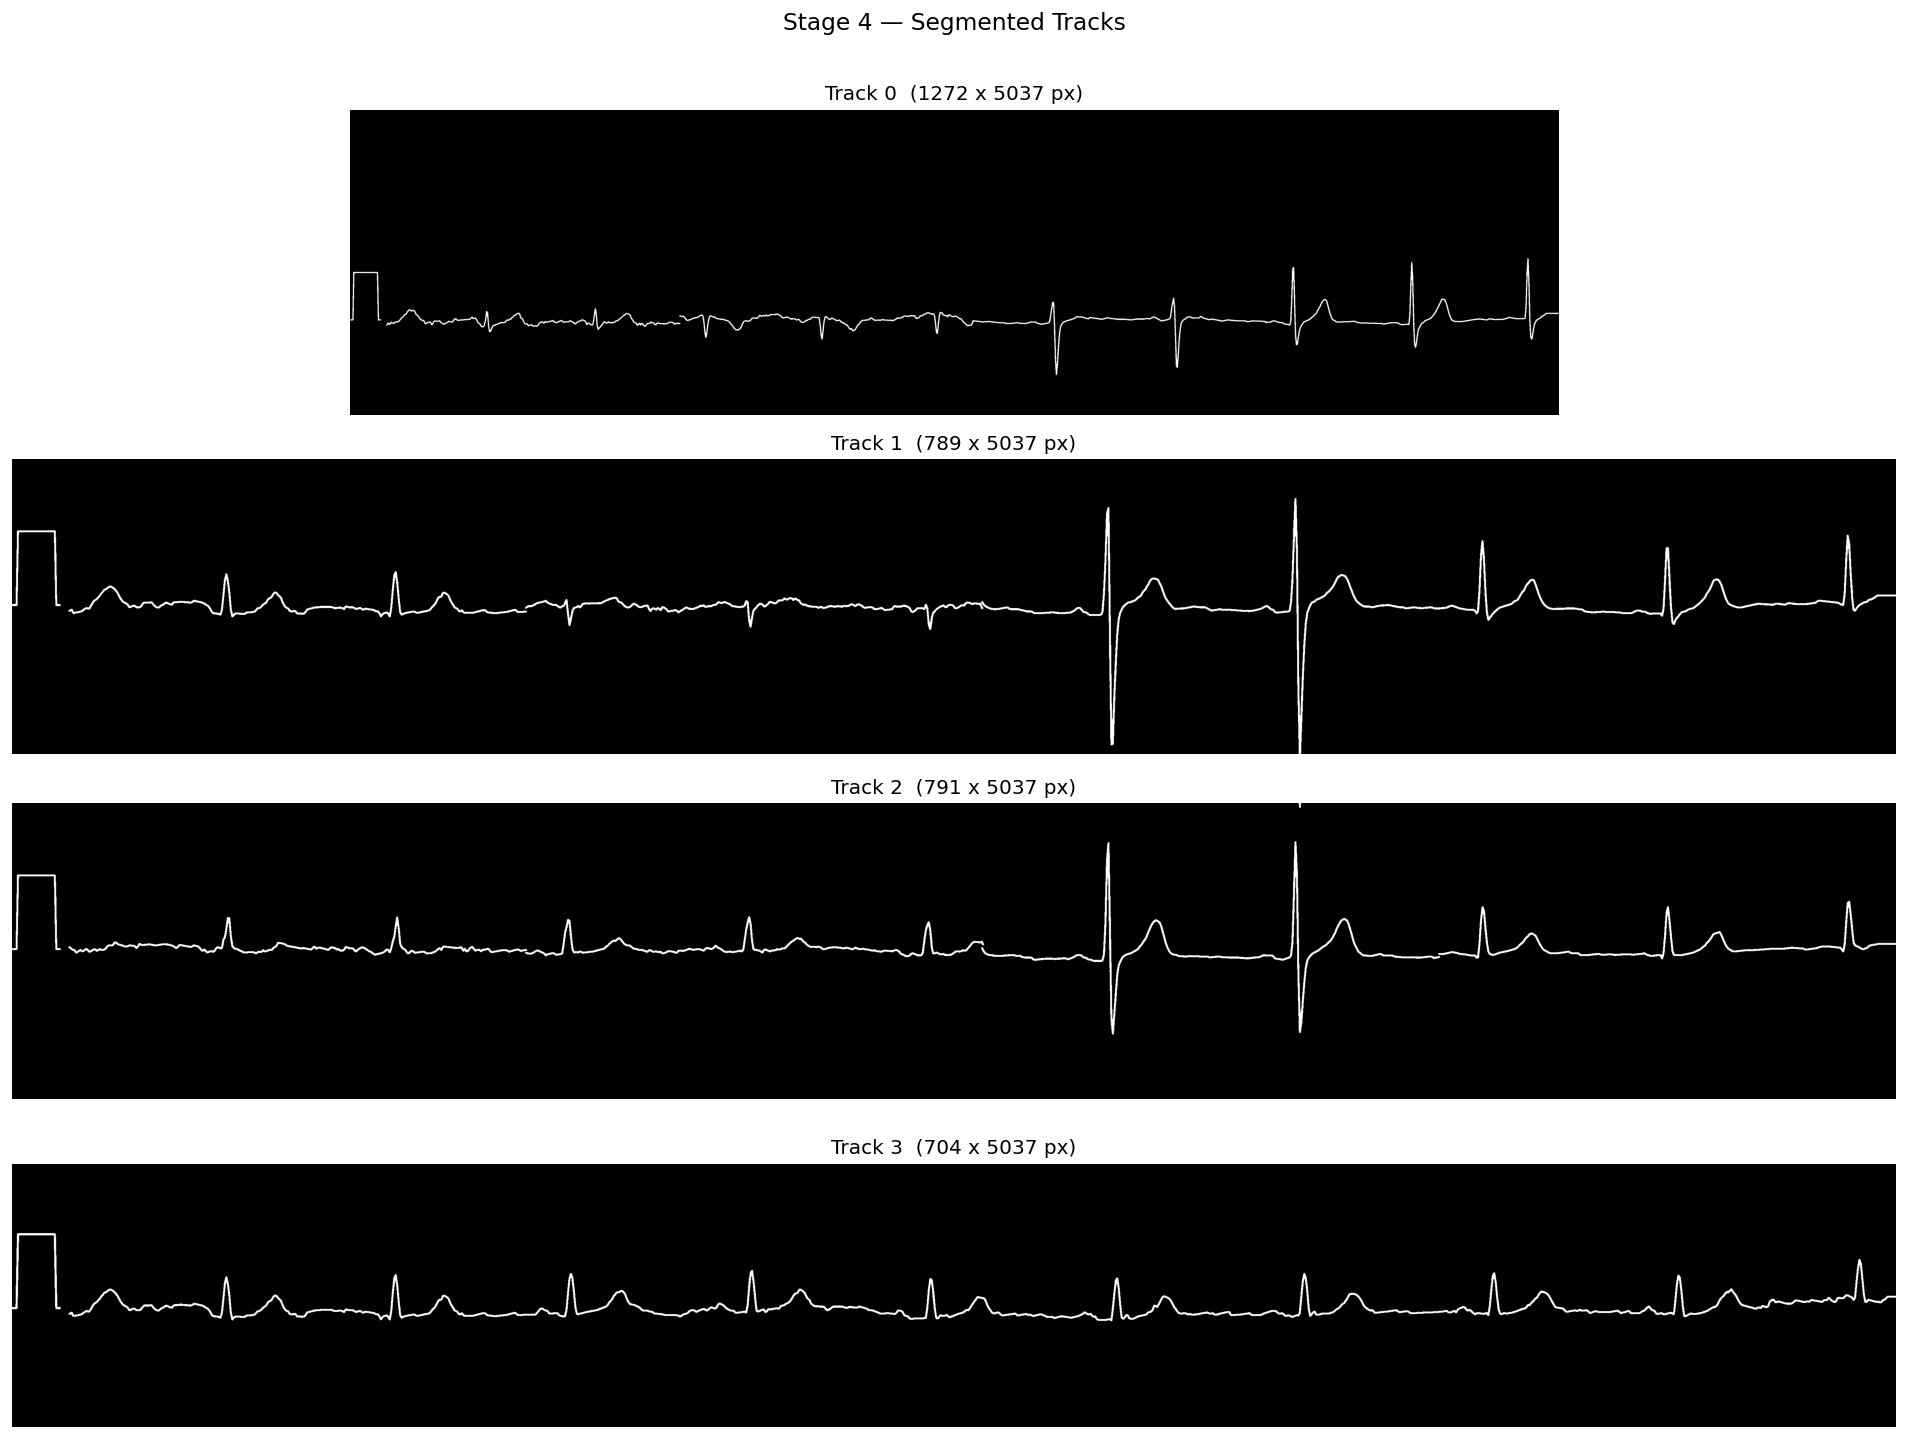

In [7]:
# Show each track as a separate subplot
n_tracks = len(dic_tracks)
fig, axes = plt.subplots(n_tracks, 1, figsize=(16, 3 * n_tracks))
if n_tracks == 1:
    axes = [axes]

for idx, (tid, track_img) in enumerate(dic_tracks.items()):
    if len(track_img.shape) == 3:
        axes[idx].imshow(track_img)
    else:
        axes[idx].imshow(track_img, cmap="gray")
    axes[idx].set_title(f"Track {tid}  ({track_img.shape[0]} x {track_img.shape[1]} px)", fontsize=12)
    axes[idx].axis("off")

fig.suptitle("Stage 4 — Segmented Tracks", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## Stage 5 — Binarized Tracks

After segmentation, the tracks are already **binarized** (white pixels = signal,
black = background). This is the input to the waveform extraction algorithms.

> **Note**: The `clean_tracks` function exists for removing small artefact
> blobs via morphological operations, but is currently not called in the
> standard pipeline. The binarization from `tracks_extraction` is sufficient
> for most ECG documents.

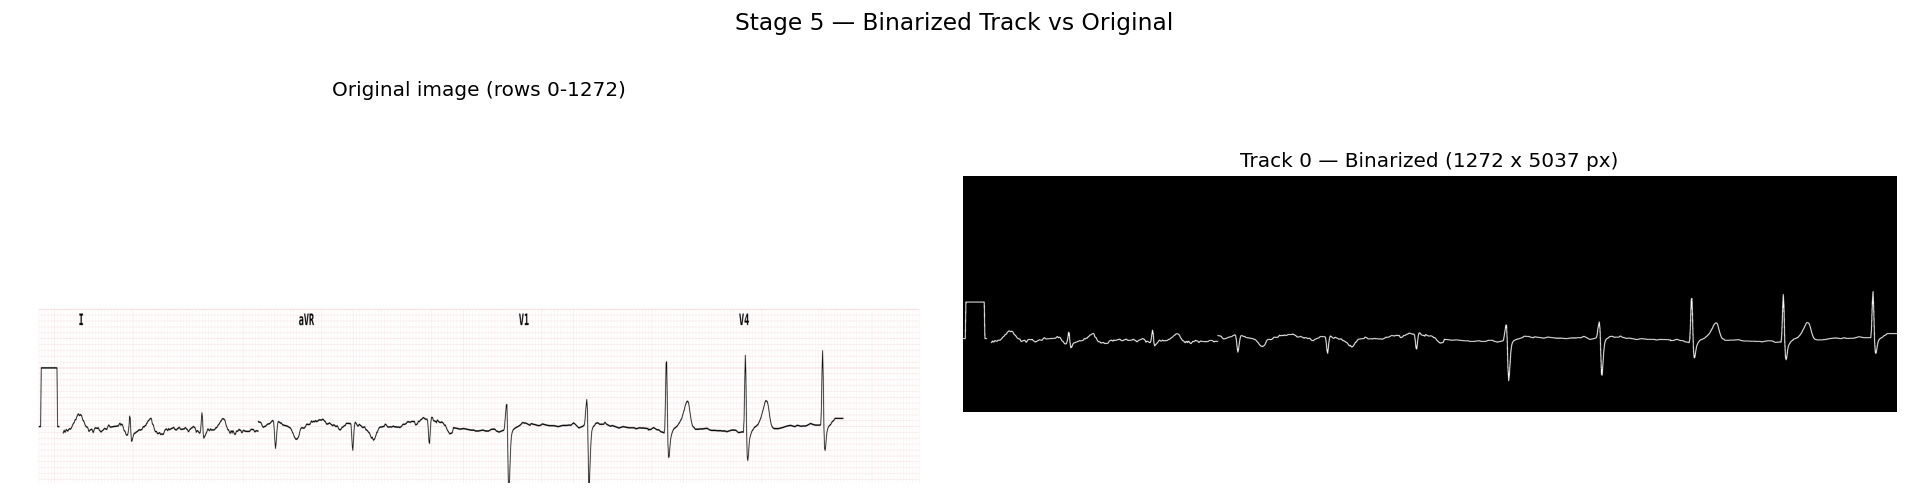

In [8]:
# Show binarized tracks
tid = list(dic_tracks.keys())[0]
track_img = dic_tracks[tid]

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Original image region (approximate) for comparison
h = image_original.shape[0]
track_h = track_img.shape[0]
# Rough vertical region of this track
y_start = max(0, peaksh[0] - track_h)
y_end = min(h, y_start + track_h)
axes[0].imshow(image_original[y_start:y_end, :], aspect="auto")
axes[0].set_title(f"Original image (rows {y_start}-{y_end})", fontsize=12)
axes[0].axis("off")

# Binarized track
if len(track_img.shape) == 3:
    axes[1].imshow(track_img)
else:
    axes[1].imshow(track_img, cmap="gray")
axes[1].set_title(f"Track {tid} — Binarized ({track_img.shape[0]} x {track_img.shape[1]} px)", fontsize=12)
axes[1].axis("off")

fig.suptitle("Stage 5 — Binarized Track vs Original", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Stage 6 — Waveform Extraction (Binarization + Pixel-to-Signal)

`lead_extraction` binarizes each track and applies the selected extraction
algorithm to convert pixel positions into a 1-D signal. The signal is then
time-scaled to a standard length (5140 samples for classic format).

Returns:
- `dic_extracted`: scaled signals (standard sample count)
- `dic_image_bin`: binarized track images
- `dic_not_scaled`: raw pixel-level signals before time scaling

In [9]:
dic_extracted, dic_image_bin, dic_not_scaled = lead_extraction(
    dic_tracks, "fragmented", TYPE, NOISE=NOISE, DEBUG=False
)

print("Extracted signals:")
for tid in dic_extracted:
    raw_len = len(dic_not_scaled[tid])
    scaled_len = len(dic_extracted[tid])
    print(f"  Track {tid}: {raw_len} px  ->  {scaled_len} samples (time-scaled)")

Extracted signals:
  Track 0: 5036 px  ->  5140 samples (time-scaled)
  Track 1: 5036 px  ->  5140 samples (time-scaled)
  Track 2: 5036 px  ->  5140 samples (time-scaled)
  Track 3: 5036 px  ->  5140 samples (time-scaled)


/Users/eprifti/.venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/eprifti/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


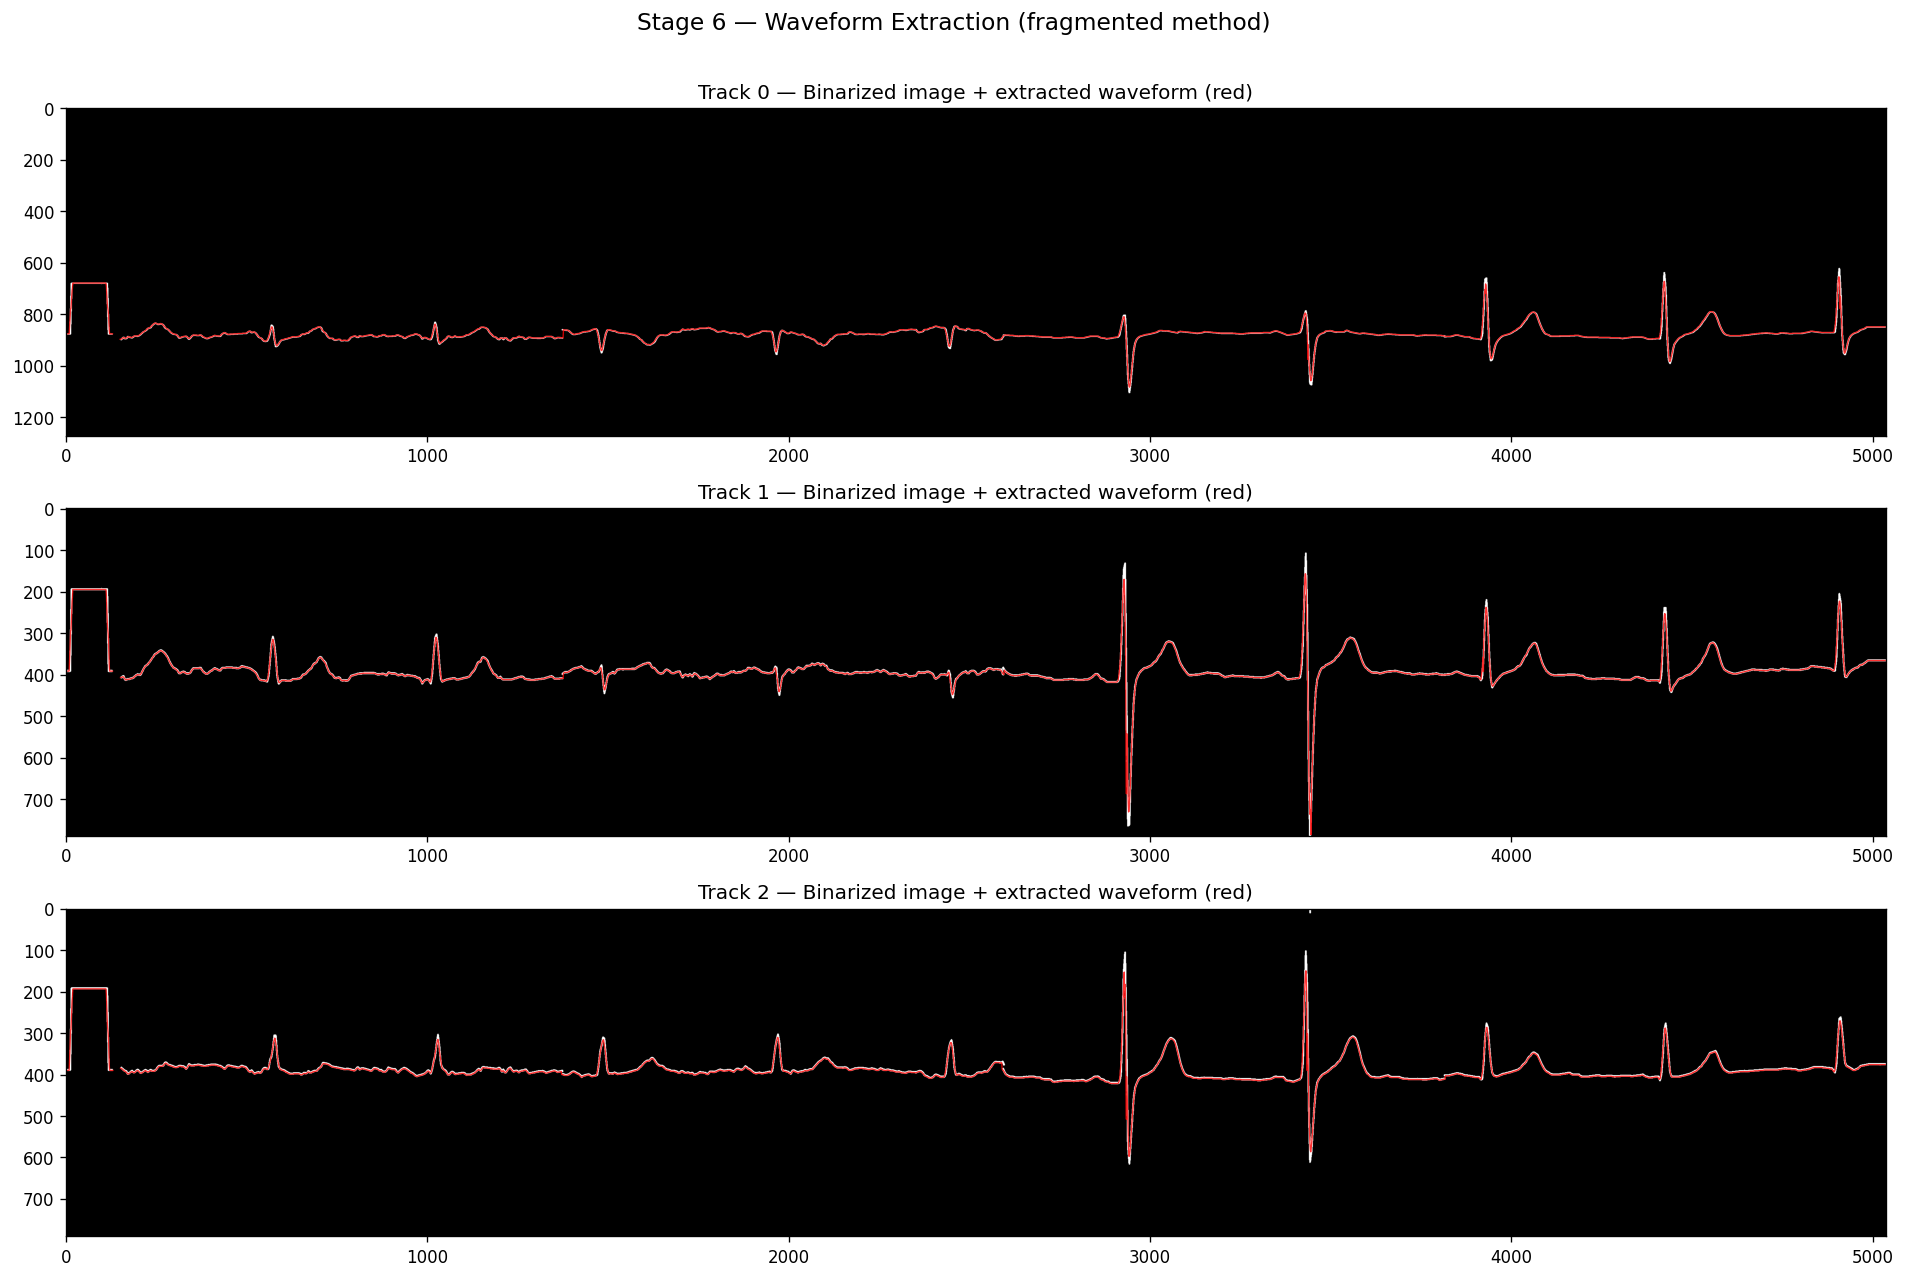

In [10]:
# Show binarized track + extracted waveform overlay
n = min(3, len(dic_tracks))
fig, axes = plt.subplots(n, 1, figsize=(16, 3.5 * n))
if n == 1:
    axes = [axes]

for idx, tid in enumerate(list(dic_tracks.keys())[:n]):
    bin_img = dic_image_bin[tid]
    signal_raw = dic_not_scaled[tid]

    axes[idx].imshow(bin_img, cmap="gray", aspect="auto")
    axes[idx].plot(signal_raw, color="red", linewidth=0.8, alpha=0.8)
    axes[idx].set_title(f"Track {tid} — Binarized image + extracted waveform (red)", fontsize=12)
    axes[idx].set_xlim(0, bin_img.shape[1])

fig.suptitle("Stage 6 — Waveform Extraction (fragmented method)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## Stage 7 — Compare Extraction Methods

ECGtizer provides three extraction algorithms with different trade-offs:

| Method | Speed | Accuracy | Description |
|--------|-------|----------|-------------|
| **lazy** | Fast | Moderate | Follows nearest lit pixel from anchor |
| **full** | Fast | High | Averages all lit pixel positions per column |
| **fragmented** | Slower | Highest | Contour detection separates signal from text |

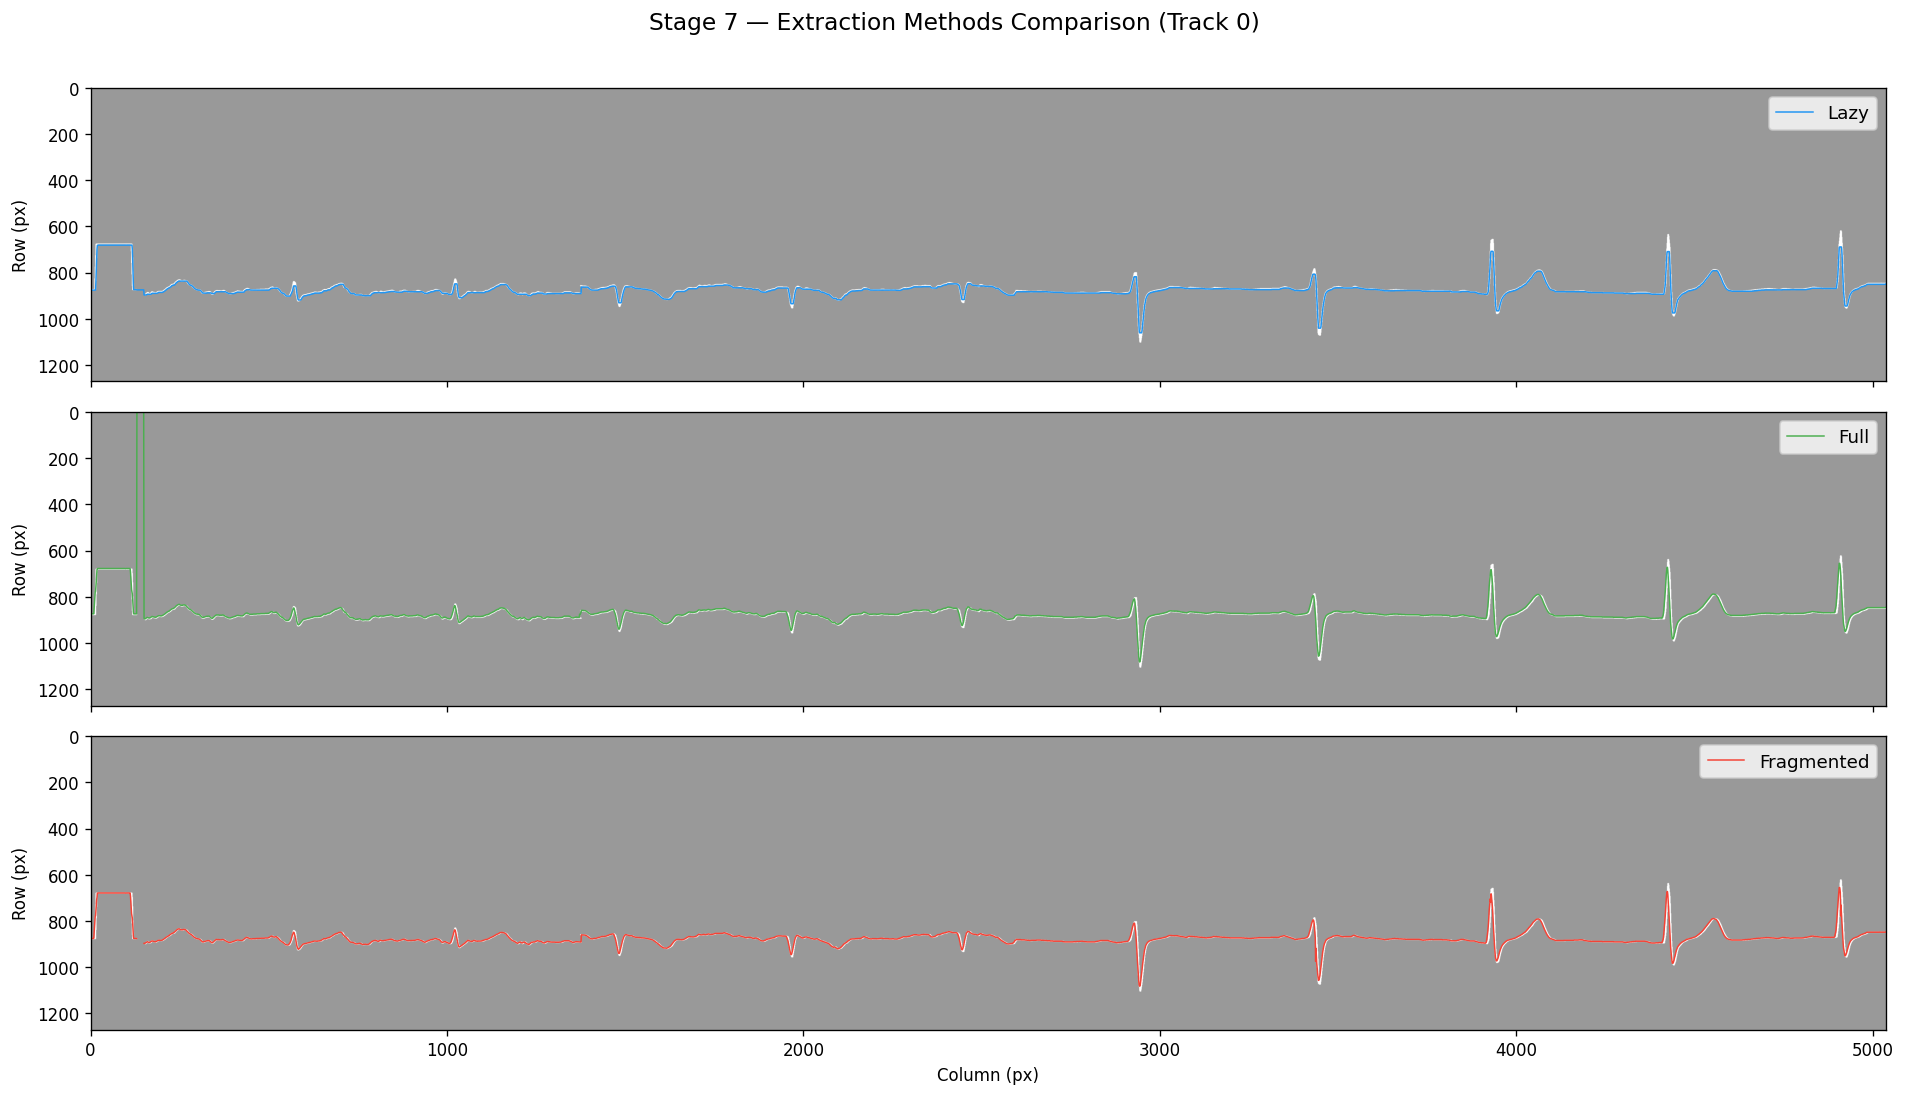

In [11]:
# Compare all three methods on the first track
tid = list(dic_image_bin.keys())[0]
bin_img = dic_image_bin[tid]

sig_lazy = lazy_extraction(bin_img)
sig_full = full_extraction(bin_img)
sig_frag = fragmented_extraction(bin_img)

fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)
methods = [(sig_lazy, "Lazy", "#2196F3"),
           (sig_full, "Full", "#4CAF50"),
           (sig_frag, "Fragmented", "#F44336")]

for ax, (sig, name, color) in zip(axes, methods):
    ax.imshow(bin_img, cmap="gray", aspect="auto", alpha=0.4)
    ax.plot(sig, color=color, linewidth=0.9, label=name)
    ax.set_xlim(0, bin_img.shape[1])
    ax.legend(loc="upper right", fontsize=11)
    ax.set_ylabel("Row (px)")

axes[-1].set_xlabel("Column (px)")
fig.suptitle("Stage 7 — Extraction Methods Comparison (Track 0)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## Stage 8 — Lead Calibration & Naming

`lead_cutting` performs two critical operations:

1. **Amplitude calibration**: extracts the reference pulse (1 mV calibration
   square) at the start of each track to determine the pixel-to-microvolt
   conversion factor.

2. **Lead segmentation**: cuts each track into named leads based on the
   detected layout (3x4 or 6x2) and assigns standard lead names
   (I, II, III, aVR, aVL, aVF, V1-V6).

In [12]:
dic_lead = lead_cutting(
    dic_extracted, DPI, TYPE, FORMAT="", page=0, NOISE=NOISE, DEBUG=False
)

print(f"Detected layout: {'3x4' if len(dic_tracks) == 4 else '6x2'}")
print(f"Number of leads: {len(dic_lead)}")
print()
print(f"{'Lead':<6} {'Samples':>8} {'Min (uV)':>10} {'Max (uV)':>10}")
print("-" * 36)
for name, signal in dic_lead.items():
    print(f"{name:<6} {len(signal):>8} {min(signal):>10.0f} {max(signal):>10.0f}")

Detected layout: 3x4
Number of leads: 13

Lead    Samples   Min (uV)   Max (uV)
------------------------------------
I          5000        nan        nan
AVR        5000       -352        157
V1         5000      -1045        409
V4         5000       -542       1122
II         5000        nan        nan
AVL        5000       -285         99
V2         5000      -1951       1189
V5         5000       -245        854
III        5000        nan        nan
AVF        5000        -96        404
V3         5000      -1053       1216
V6         5000       -111        607
IIc        5000        nan        nan


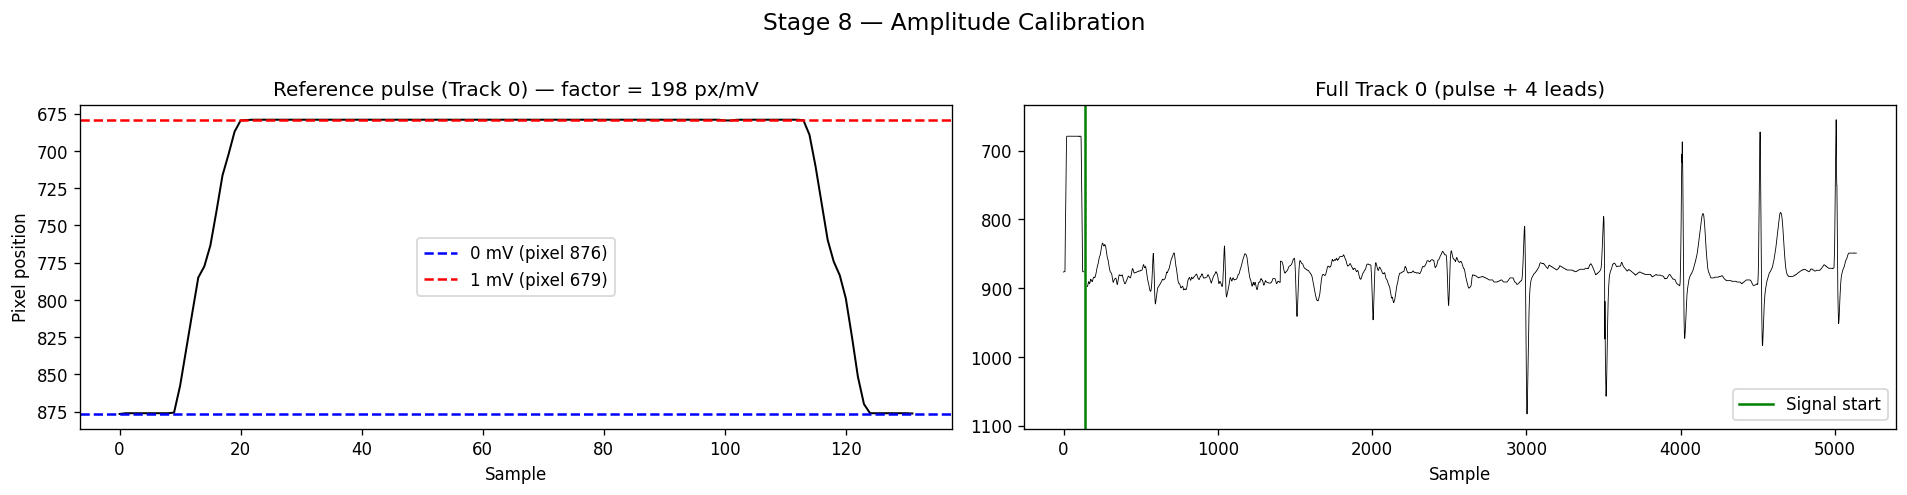

In [13]:
# Show reference pulse calibration for track 0
track0 = dic_extracted[0]

# The reference pulse is at the beginning of the track
from ecgtizer.PDF2XML import REF_PULSE_CLASSIC, SIGNAL_LENGTH_STANDARD
length_pulse = len(track0) - SIGNAL_LENGTH_STANDARD
ref_pulse = track0[:length_pulse]

pixel_zero = max(ref_pulse)  # 0 mV baseline
pixel_one = min(ref_pulse)   # 1 mV level
f = pixel_zero - pixel_one   # Scaling factor

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Reference pulse
axes[0].plot(ref_pulse, "k-", linewidth=1.2)
axes[0].axhline(pixel_zero, color="blue", linestyle="--", label=f"0 mV (pixel {pixel_zero:.0f})")
axes[0].axhline(pixel_one, color="red", linestyle="--", label=f"1 mV (pixel {pixel_one:.0f})")
axes[0].set_title(f"Reference pulse (Track 0) — factor = {f:.0f} px/mV")
axes[0].set_xlabel("Sample")
axes[0].set_ylabel("Pixel position")
axes[0].invert_yaxis()
axes[0].legend(fontsize=10)

# Full track showing pulse + signal
axes[1].plot(track0, "k-", linewidth=0.5)
axes[1].axvline(length_pulse, color="green", linewidth=1.5, label="Signal start")
axes[1].set_title("Full Track 0 (pulse + 4 leads)")
axes[1].set_xlabel("Sample")
axes[1].invert_yaxis()
axes[1].legend(fontsize=10)

fig.suptitle("Stage 8 — Amplitude Calibration", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Stage 9 — Final 12-Lead ECG Plot

The digitized leads are now calibrated in microvolts. We plot them using
`plot_function` which renders a standard 12-lead ECG grid.

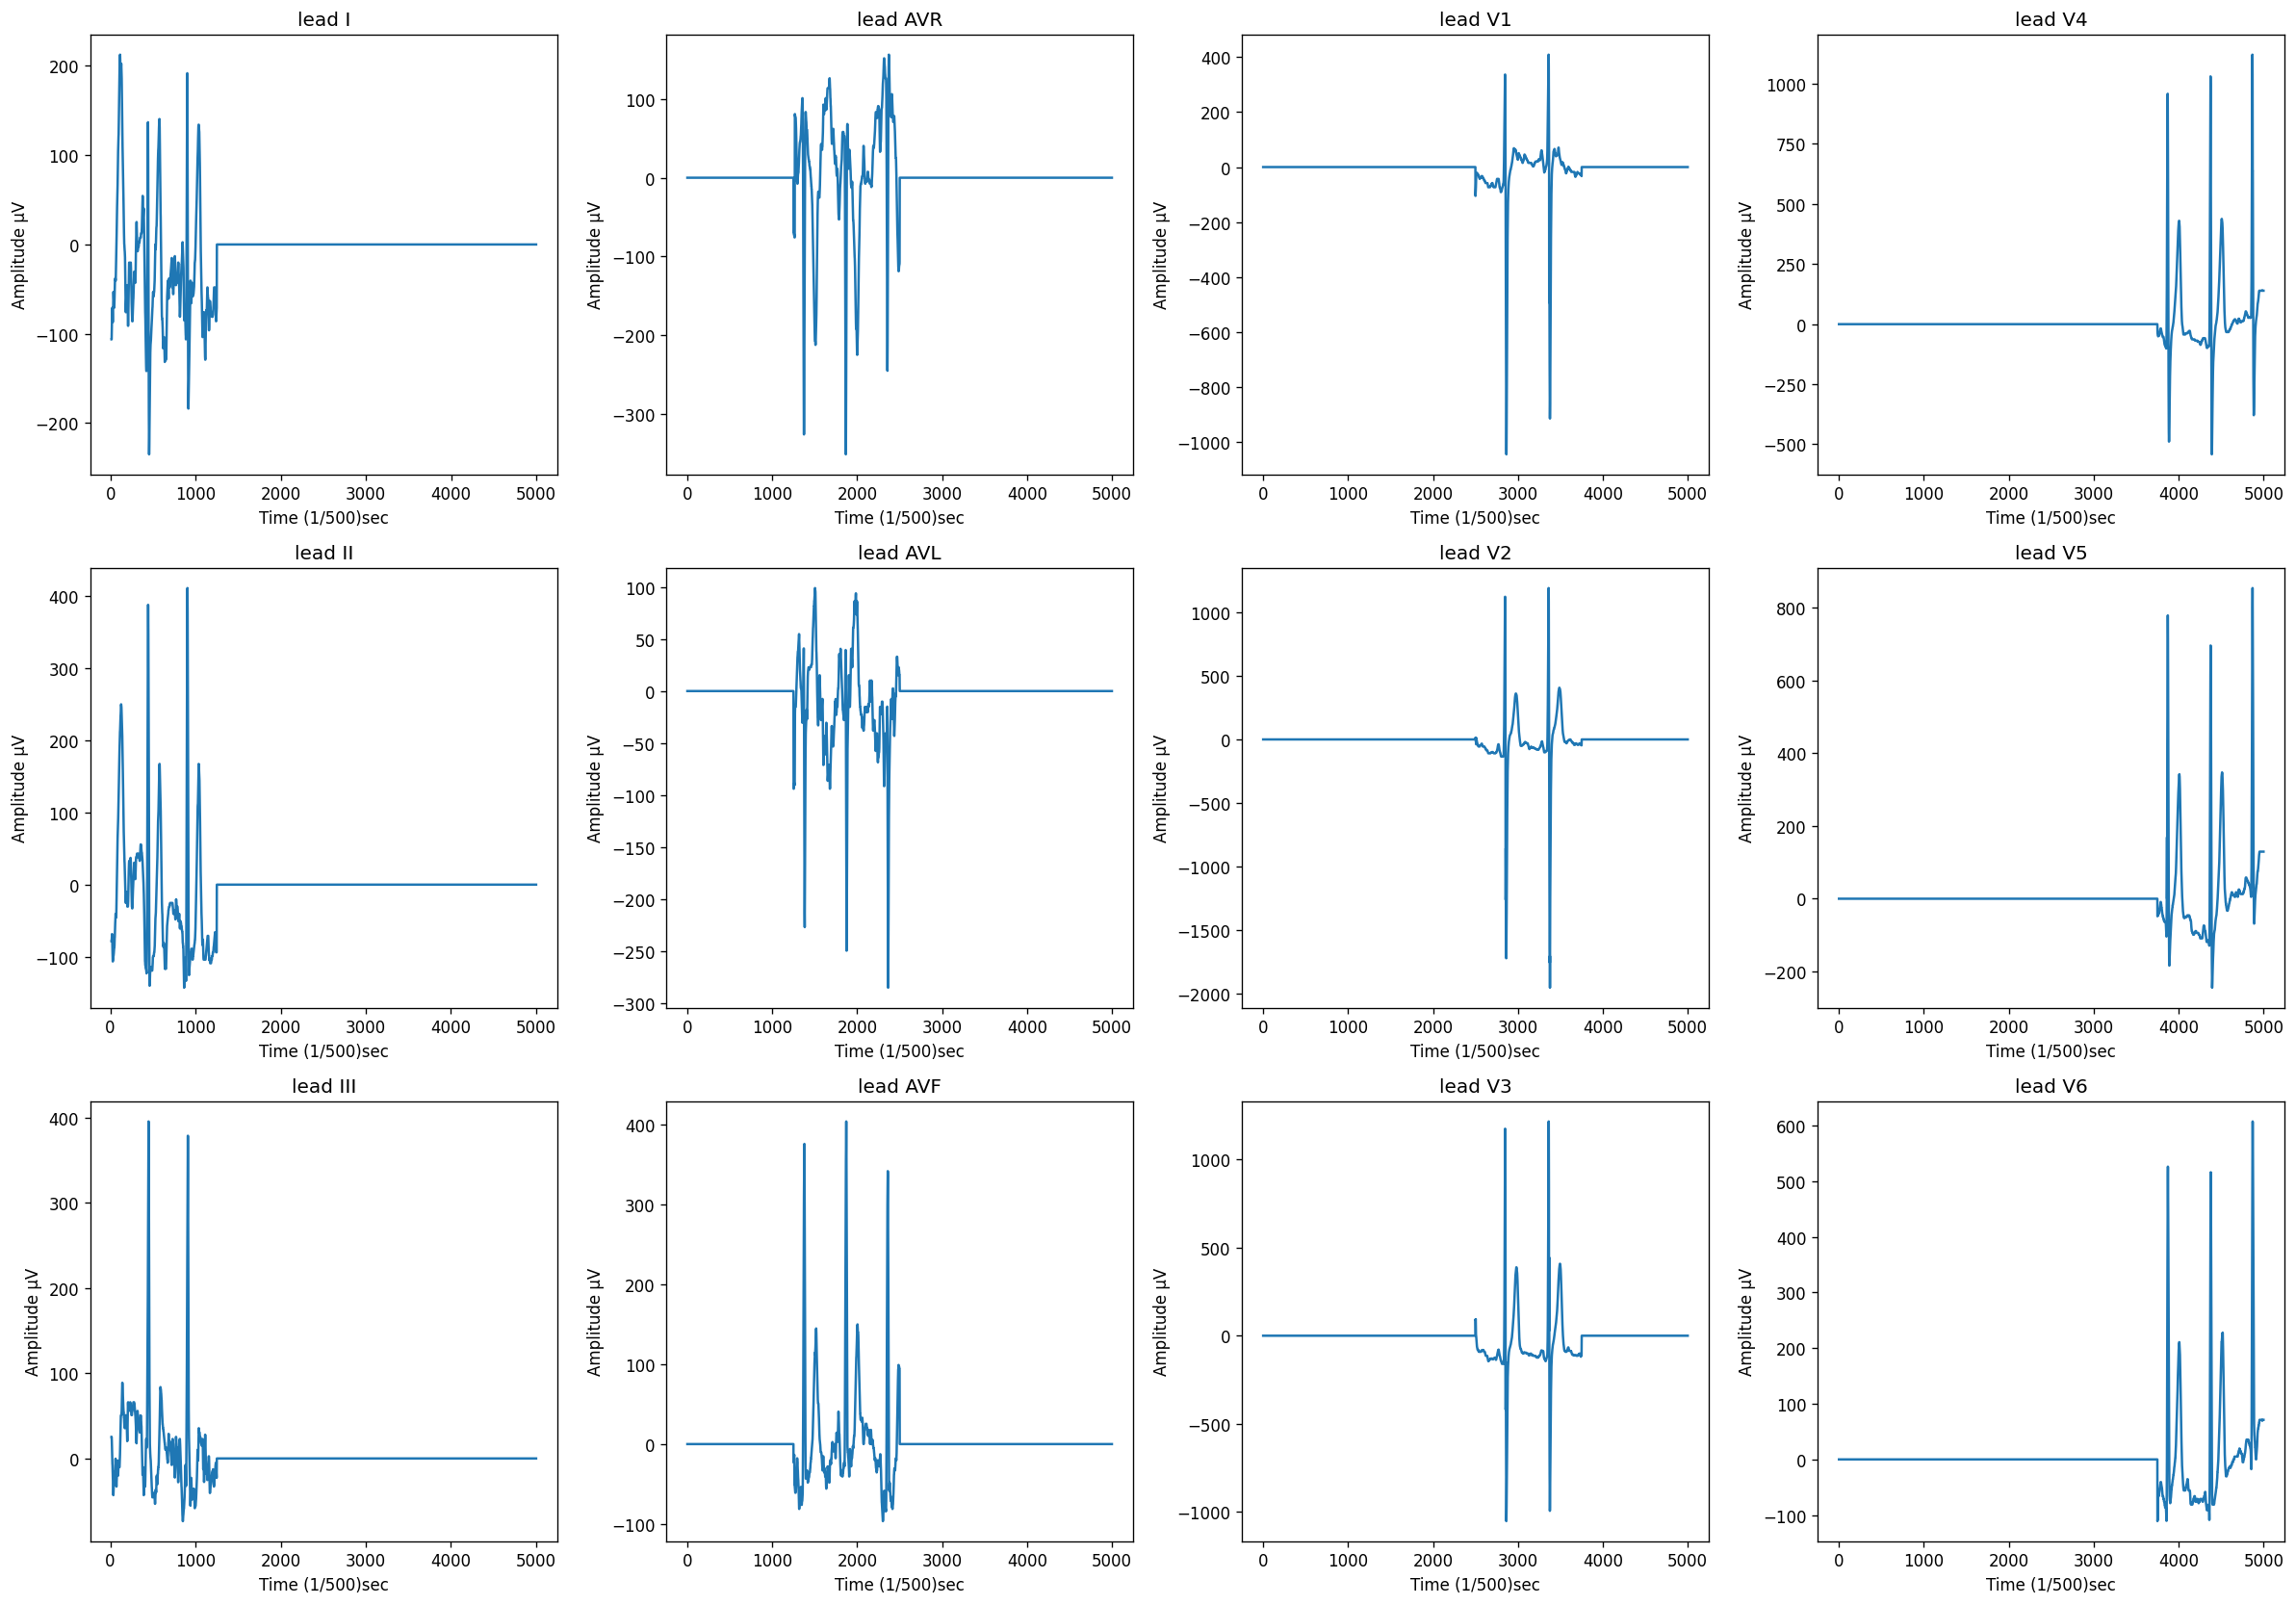

In [14]:
plot_function(dic_lead)

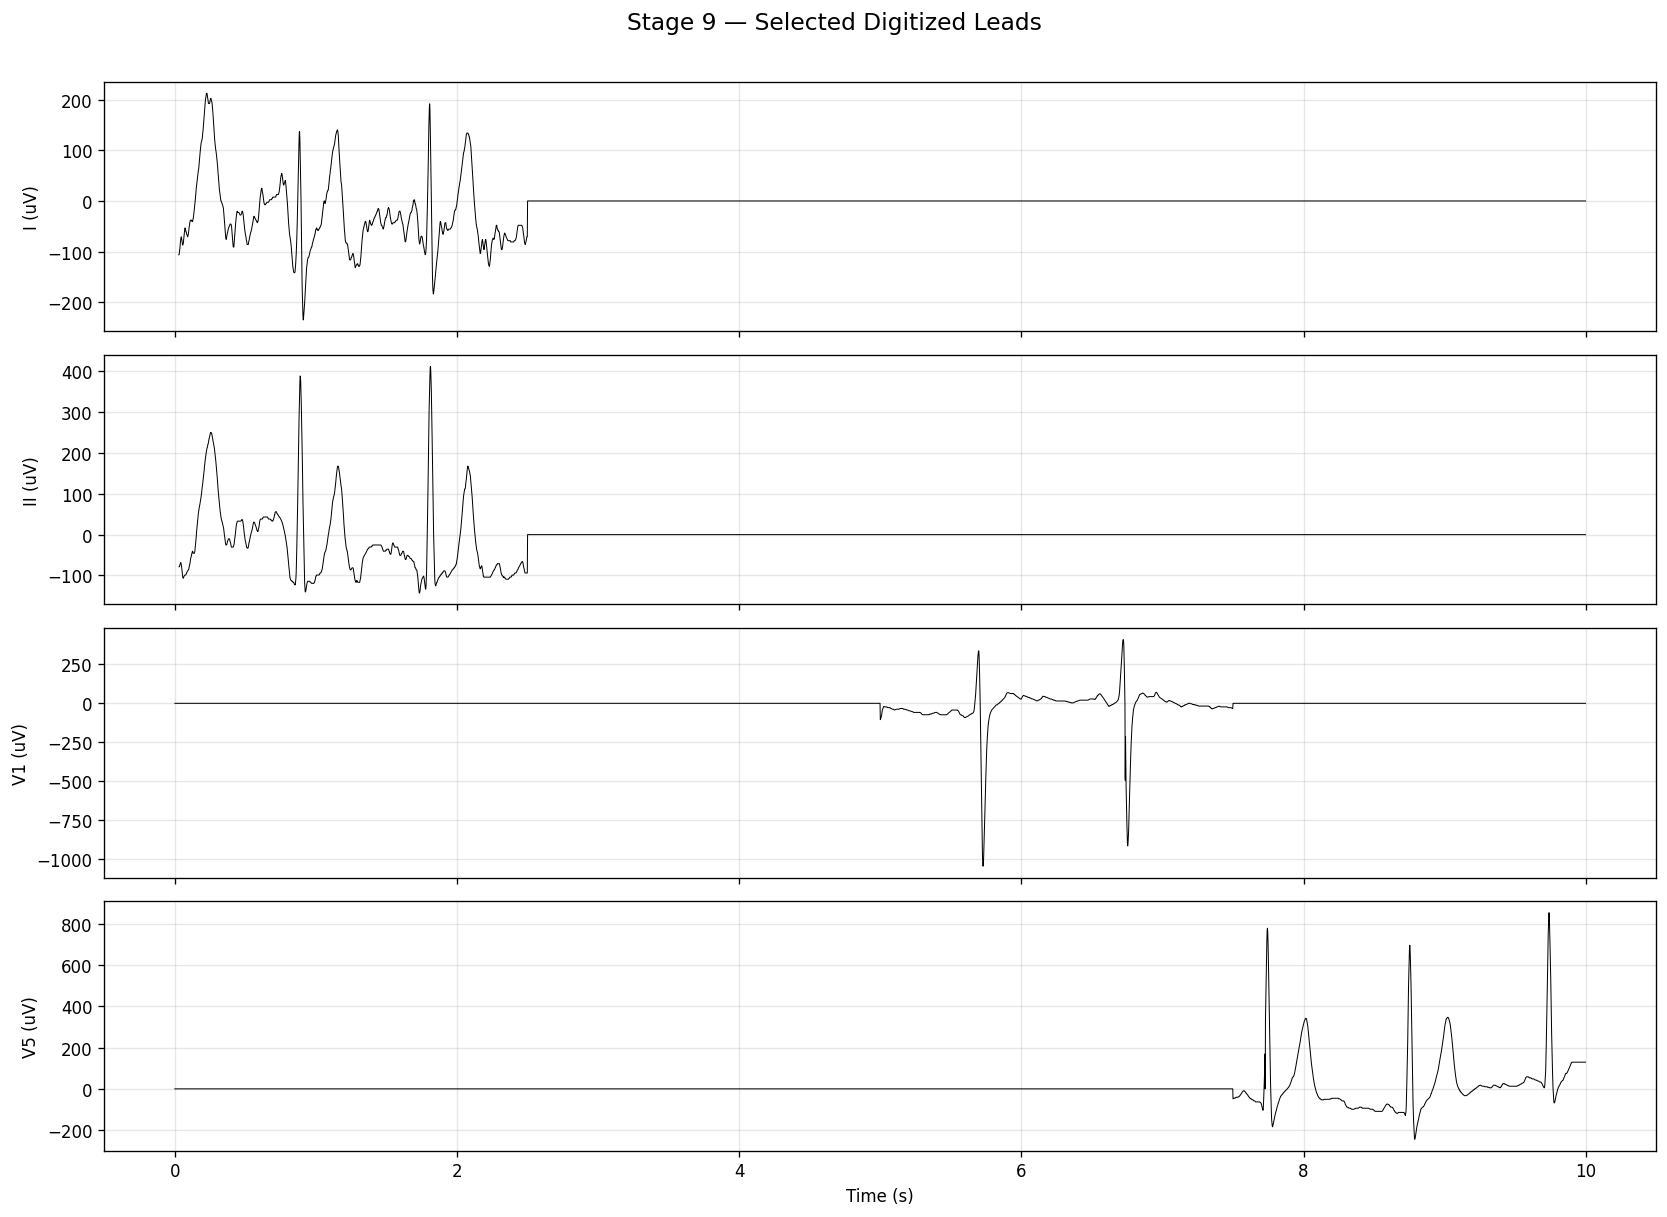

In [15]:
# Individual lead plots
leads_to_show = ["I", "II", "V1", "V5"]
fig, axes = plt.subplots(len(leads_to_show), 1, figsize=(14, 2.5 * len(leads_to_show)), sharex=True)

for ax, name in zip(axes, leads_to_show):
    if name in dic_lead:
        signal = dic_lead[name]
        t = np.arange(len(signal)) / 500  # time in seconds
        ax.plot(t, signal, "k-", linewidth=0.6)
        ax.set_ylabel(f"{name} (uV)")
        ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Stage 9 — Selected Digitized Leads", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## Stage 10 — Overlay Verification

We overlay the extracted waveforms (red) on the original ECG image to
visually verify extraction quality. The waveforms should follow the
printed traces.

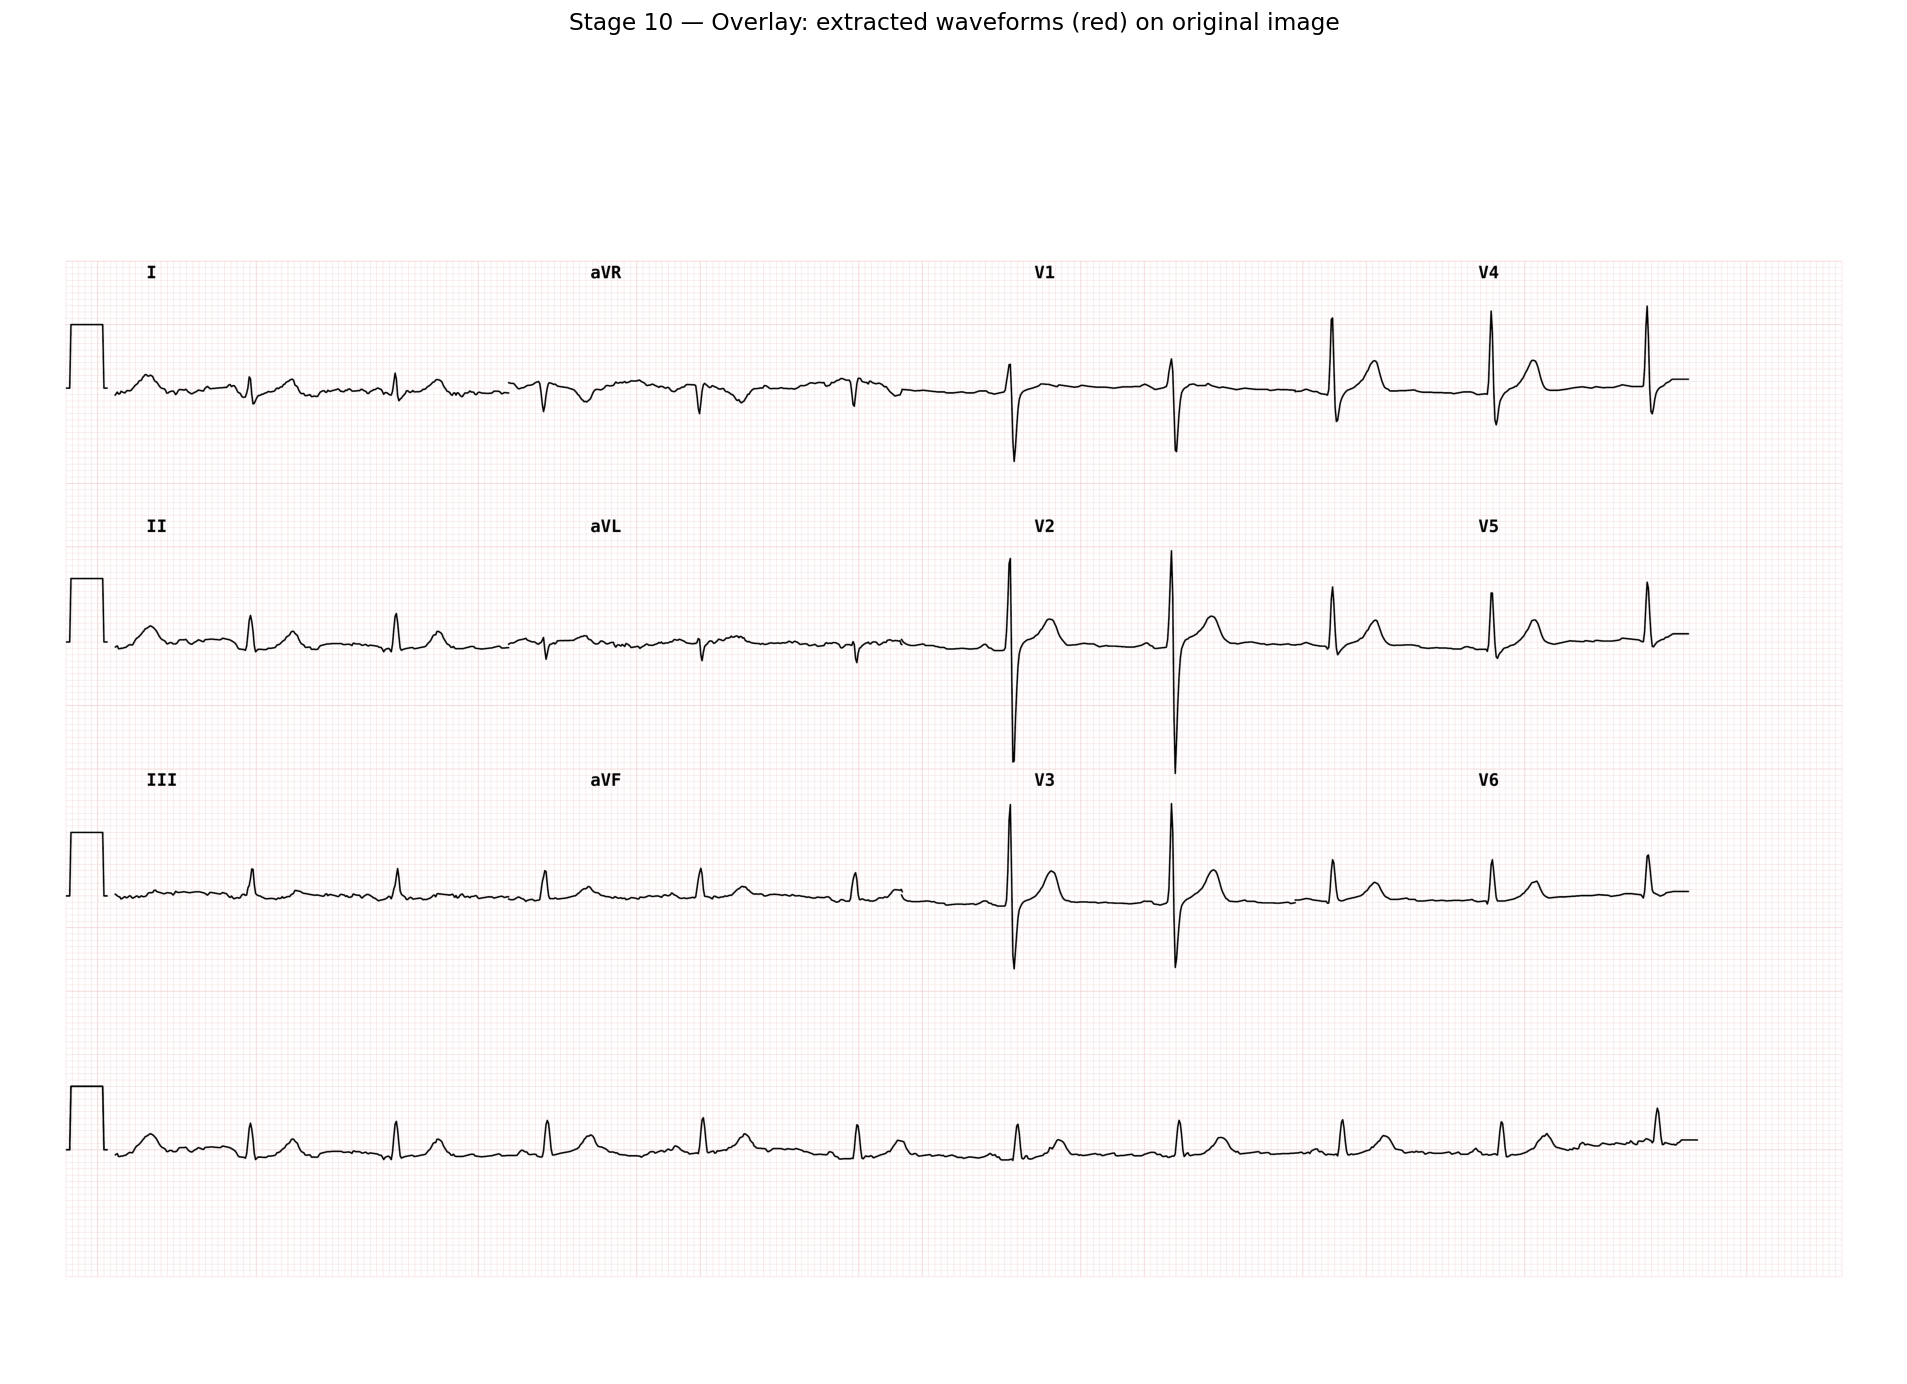

In [16]:
fig, ax = plt.subplots(figsize=(16, 12))
ax.imshow(image_original, cmap="gray")

# Overlay each track's raw signal on the original image
for tid in dic_not_scaled:
    signal = dic_not_scaled[tid]
    # Compute vertical offset: align signal median with track peak position
    median_sig = np.median(signal)
    offset = peaksh[tid] - median_sig
    # Horizontal padding to align with signal start column
    x = np.arange(peaksv, peaksv + len(signal))
    ax.plot(x, signal + offset, color="red", linewidth=0.7, alpha=0.85)

ax.set_title("Stage 10 — Overlay: extracted waveforms (red) on original image", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

---
## Stage 11 — Export to HL7 aECG XML

`write_xml` serializes the digitized leads into an HL7 aECG XML file,
the standard format for digital ECG storage.

In [17]:
os.makedirs("output", exist_ok=True)
xml_path = "output/vignette_00009.xml"

# Metadata table (minimal)
table = {
    "BPM": "75", "low_freq": "0.05", "high_freq": "150",
    "Inter PR (ms)": "160", "Dur.QRS (ms)": "90",
    "QT (ms)": "380", "QTc (ms)": "410",
    "Axe P": "60", "Axe R": "30", "Axe T": "45",
    "Moy RR (ms)": "800", "QTcB (ms)": "405", "QTcF (ms)": "400",
    "Rythme": "Sinus", "ECG": "Normal",
    "Age": "60", "sex": "M", "other_information": "Vignette example",
}

write_xml(dic_lead, xml_path, TYPE=TYPE, table=table)
print(f"XML written to: {xml_path}")
print(f"File size: {os.path.getsize(xml_path):,} bytes")

XML written to: output/vignette_00009.xml
File size: 1,122,582 bytes


---
## Stage 12 — Re-render as PDF

As a final step, we can re-render the digitized signals back to a
publication-quality PDF using `xml_to_pdf`.

In [18]:
from ecgtizer.XML2PDF import xml_to_pdf

pdf_path = "output/vignette_00009.pdf"
xml_to_pdf(xml_path, pdf_path, type_of_pdf="type1")
print(f"PDF written to: {pdf_path}")
print(f"File size: {os.path.getsize(pdf_path):,} bytes")
print("\nOpen the PDF to see the re-rendered 12-lead ECG.")

PDF written to: output/vignette_00009.pdf
File size: 47,788 bytes

Open the PDF to see the re-rendered 12-lead ECG.


---
## Summary

| Stage | Function | Input | Output |
|-------|----------|-------|--------|
| 1 | `convert_PDF2image` | PDF file | RGB image (NumPy array) |
| 2 | `check_noise_type` | Image | TYPE (str), NOISE (bool/float) |
| 3 | `text_extraction` | Image | Masked image (text regions whitened) |
| 4 | `tracks_extraction` | Masked image | Dict of track sub-images |
| 5 | `clean_tracks` | Track images | Cleaned track images |
| 6 | `lead_extraction` | Track images | 1-D signals (raw + time-scaled) |
| 7 | lazy/full/fragmented | Binary track | Comparison of 3 algorithms |
| 8 | `lead_cutting` | Scaled signals | Named leads calibrated in uV |
| 9 | `plot_function` | Lead dict | 12-lead ECG grid plot |
| 10 | overlay | Original image + signals | Visual verification |
| 11 | `write_xml` | Lead dict | HL7 aECG XML file |
| 12 | `xml_to_pdf` | XML file | Publication-quality PDF |

For more details, see the [API Reference](api/index.rst) documentation.